# RS-AGGNM: Regime-Switching Adaptive Graph-Gated Network Markowitz
**Dokumentasi Tesis** | `RS_AGGNM_Tesis.ipynb`

Model portofolio usulan tesis yang mengintegrasikan:
- **Inovasi 1:** Gaussian HMM 2-state untuk deteksi regime Bull/Bear
- **Inovasi 2:** Maximum Independent Set (MIS) dengan optimasi θ Out-of-Sample
- **Inovasi 3:** RS-AGGNM Framework — jaringan + optimasi varians adaptif

---
## Sel 1 — Library dan Konfigurasi Global

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
from scipy.optimize import minimize
from scipy.linalg import eigh
from scipy.stats import norm as stats_norm
from sklearn.covariance import GraphicalLasso, LedoitWolf
from itertools import combinations

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# ── Parameter Global ──────────────────────────────────────────────────────────
WINDOW_SIZE    = 120   # rolling window (hari)
REBALANCE_FREQ = 7     # rebalancing (hari)
TRANS_COST     = 0.001 # 10 bps per turnover unit

print("✅ Library berhasil dimuat.")
print(f"   WINDOW_SIZE    = {WINDOW_SIZE} hari")
print(f"   REBALANCE_FREQ = {REBALANCE_FREQ} hari")
print(f"   TRANS_COST     = {TRANS_COST} (10 bps)")

✅ Library berhasil dimuat.
   WINDOW_SIZE    = 120 hari
   REBALANCE_FREQ = 7 hari
   TRANS_COST     = 0.001 (10 bps)


---
## Sel 2 — Memuat Dataset Kripto

In [2]:
EXCEL_FILE = 'crypto_data_real.xlsx'

df_returns = pd.read_excel(
    EXCEL_FILE, sheet_name='Returns', index_col=0, parse_dates=True
)
df_prices = pd.read_excel(
    EXCEL_FILE, sheet_name='Prices', index_col=0, parse_dates=True
)

df_returns.dropna(inplace=True)
df_prices.dropna(inplace=True)

crypto_names = df_returns.columns.tolist()
N_ASSETS     = len(crypto_names)

print(f"✅ Data berhasil dimuat.")
print(f"   Aset           : {crypto_names}")
print(f"   Jumlah Aset    : {N_ASSETS}")
print(f"   Rentang Tanggal: {df_returns.index[0].date()} s/d {df_returns.index[-1].date()}")
print(f"   Jumlah Observasi: {len(df_returns)}")
df_returns.head()

✅ Data berhasil dimuat.
   Aset           : ['BTC', 'ETH', 'XRP', 'USDT', 'BCH', 'LTC', 'BNB', 'EOS', 'XLM', 'TRX']
   Jumlah Aset    : 10
   Rentang Tanggal: 2017-09-15 s/d 2019-10-17
   Jumlah Observasi: 763


,BTC,ETH,XRP,USDT,BCH,LTC,BNB,EOS,XLM,TRX
Date,,,,,,,,,,
2017-09-15,0.142330,0.0,0.0,0.0,0.0,0.147883,0.0,0.0,0.0,0.0
2017-09-16,-0.003437,0.0,0.0,0.0,0.0,0.000947,0.0,0.0,0.0,0.0
2017-09-17,-0.011698,0.0,0.0,0.0,0.0,0.004794,0.0,0.0,0.0,0.0
2017-09-18,0.126296,0.0,0.0,0.0,0.0,0.135479,0.0,0.0,0.0,0.0
2017-09-19,-0.035104,0.0,0.0,0.0,0.0,-0.049661,0.0,0.0,0.0,0.0


---
## Sel 3 — Statistik Deskriptif (Table 1)

In [3]:
summary = pd.DataFrame({
    'Mean'    : df_returns.mean(),
    'Std'     : df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew(),
}).round(4)

print("TABLE 1 | Summary Statistics of Cryptocurrency Daily Returns")
print("=" * 55)
print(summary.to_string())

# Highlight: Kurtosis tinggi → heavy-tailed → butuh RMT noise filtering
high_kurt = summary[summary['Kurtosis'] > 5]
if not high_kurt.empty:
    print(f"\n⚠️  Aset dengan Kurtosis > 5 (heavy-tailed): {list(high_kurt.index)}")
    print("   → Membenarkan perlunya penyaringan noise via Random Matrix Theory (RMT).")

TABLE 1 | Summary Statistics of Cryptocurrency Daily Returns
        Mean     Std  Kurtosis  Skewness
BTC   0.0012  0.0434    3.0822    0.0523
ETH  -0.0008  0.0507    2.8209   -0.2916
XRP   0.0004  0.0654   18.9009    2.0588
USDT -0.0000  0.0057   21.7209    0.7437
BCH  -0.0014  0.0724    7.5671    0.6231
LTC   0.0004  0.0585    6.6357    1.0988
BNB   0.0029  0.0621   10.2612    1.0694
EOS   0.0012  0.0709    4.7582    0.5781
XLM   0.0006  0.0657    7.0332    0.9799
TRX   0.0025  0.0879   22.1856    2.6905

⚠️  Aset dengan Kurtosis > 5 (heavy-tailed): ['XRP', 'USDT', 'BCH', 'LTC', 'BNB', 'XLM', 'TRX']
   → Membenarkan perlunya penyaringan noise via Random Matrix Theory (RMT).


---
## Sel 4 — Visualisasi Harga Ternormalisasi (Figure 1 & 2)

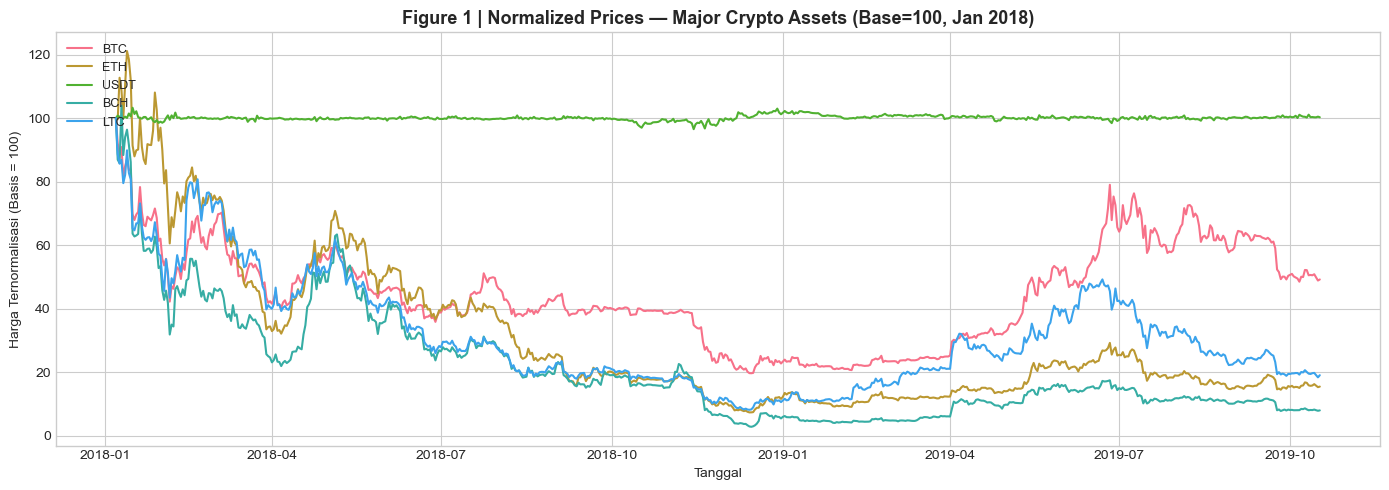

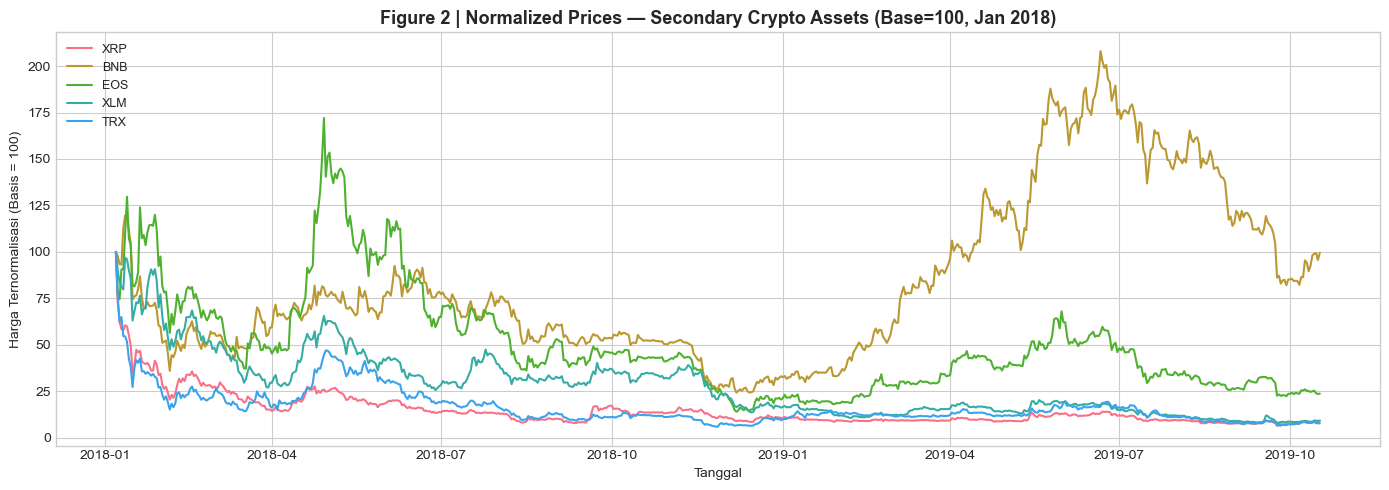

In [4]:
def plot_normalized_prices(asset_list, title, start_date='2018-01-07', figsize=(14, 5)):
    """Normalisasi harga ke basis 100 pada tanggal awal dan plot."""
    avail = [a for a in asset_list if a in df_prices.columns]
    base  = df_prices.loc[start_date:, avail]
    norm  = (base / base.iloc[0]) * 100

    fig, ax = plt.subplots(figsize=figsize)
    for col in norm.columns:
        ax.plot(norm.index, norm[col], label=col, linewidth=1.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Tanggal')
    ax.set_ylabel('Harga Ternormalisasi (Basis = 100)')
    ax.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

# Figure 1: Kelompok Aset Utama
assets_1 = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
plot_normalized_prices(
    assets_1,
    title='Figure 1 | Normalized Prices — Major Crypto Assets (Base=100, Jan 2018)'
)

# Figure 2: Kelompok Aset Sekunder (semua aset tersisa)
assets_2 = [a for a in crypto_names if a not in assets_1]
if assets_2:
    plot_normalized_prices(
        assets_2,
        title='Figure 2 | Normalized Prices — Secondary Crypto Assets (Base=100, Jan 2018)'
    )

---
## Sel 5 — MST Analysis: Bubble vs Stable (Figure 3 & 4)

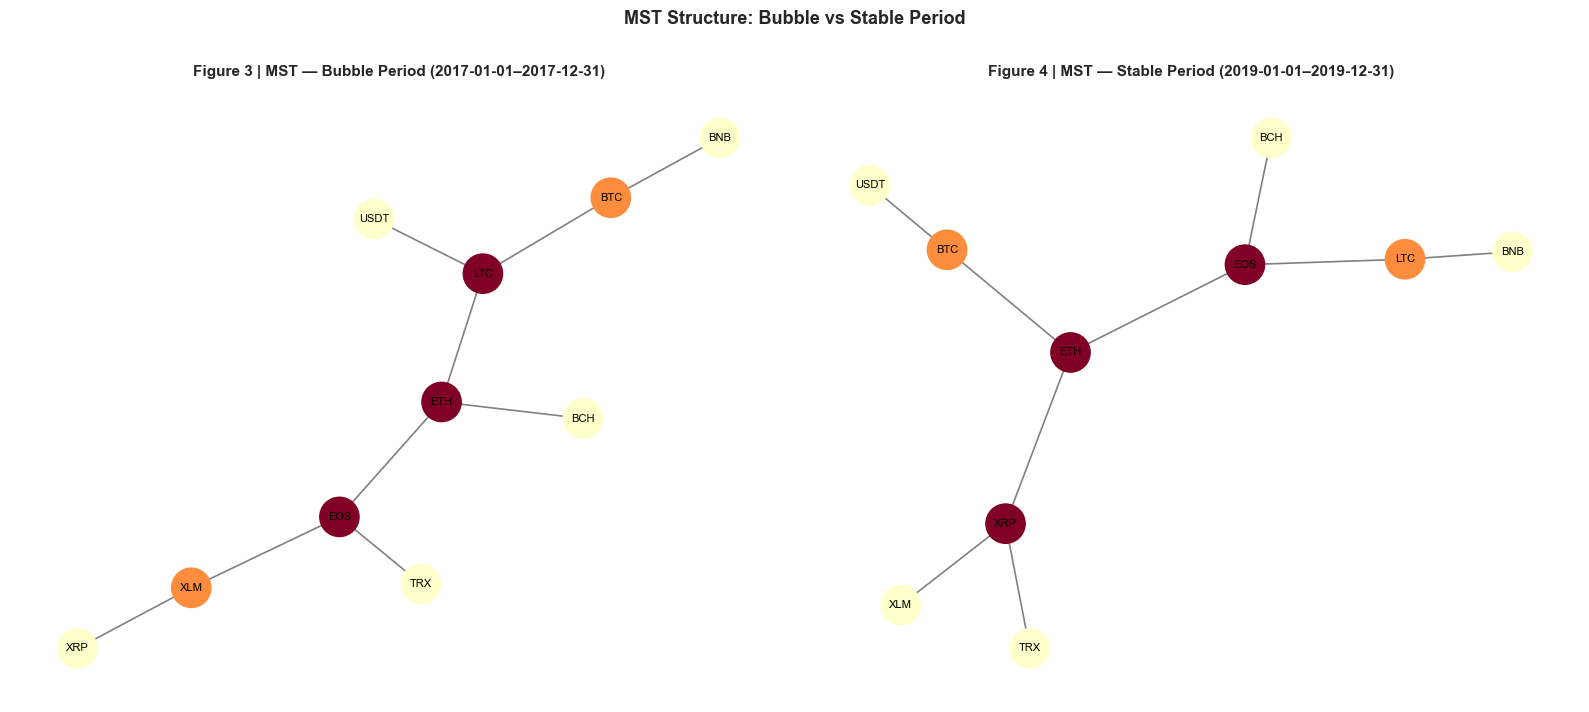

In [5]:
def build_and_draw_mst(returns_slice, title, ax, node_size=800):
    """Membangun dan menggambar Minimum Spanning Tree dari matriks korelasi."""
    corr = returns_slice.corr()
    dist = np.sqrt(2 * (1 - corr.clip(-1, 1)))

    G = nx.from_pandas_adjacency(dist)
    mst = nx.minimum_spanning_tree(G, weight='weight')

    # Warna node berdasarkan degree centrality
    centrality = nx.degree_centrality(mst)
    node_color = [centrality[n] for n in mst.nodes()]

    pos = nx.spring_layout(mst, seed=42)
    nx.draw_networkx(
        mst, pos=pos, ax=ax,
        node_color=node_color, cmap='YlOrRd',
        node_size=node_size, font_size=8,
        edge_color='gray', width=1.2, with_labels=True
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')
    return mst

# Pastikan ada data di kedua periode
bubble_period = ('2017-01-01', '2017-12-31')
stable_period  = ('2019-01-01', '2019-12-31')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Filter aset yang ada di df_returns untuk periode tersebut
def safe_slice(df, start, end):
    sl = df.loc[start:end]
    return sl.dropna(axis=1, how='all')

bubble_ret = safe_slice(df_returns, *bubble_period)
stable_ret  = safe_slice(df_returns, *stable_period)

if len(bubble_ret) > 10:
    build_and_draw_mst(
        bubble_ret,
        title=f'Figure 3 | MST — Bubble Period ({bubble_period[0]}–{bubble_period[1]})',
        ax=axes[0]
    )
else:
    axes[0].text(0.5, 0.5, 'Data tidak tersedia\nuntuk periode Bubble',
                 ha='center', va='center', transform=axes[0].transAxes)
    axes[0].axis('off')

if len(stable_ret) > 10:
    build_and_draw_mst(
        stable_ret,
        title=f'Figure 4 | MST — Stable Period ({stable_period[0]}–{stable_period[1]})',
        ax=axes[1]
    )
else:
    axes[1].text(0.5, 0.5, 'Data tidak tersedia\nuntuk periode Stable',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].axis('off')

plt.suptitle('MST Structure: Bubble vs Stable Period', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Sel 6 — MST Dynamics: Max Link & Residuality (Figure 5)

⏳ Menghitung MST Dynamics (rolling window)... Harap tunggu.


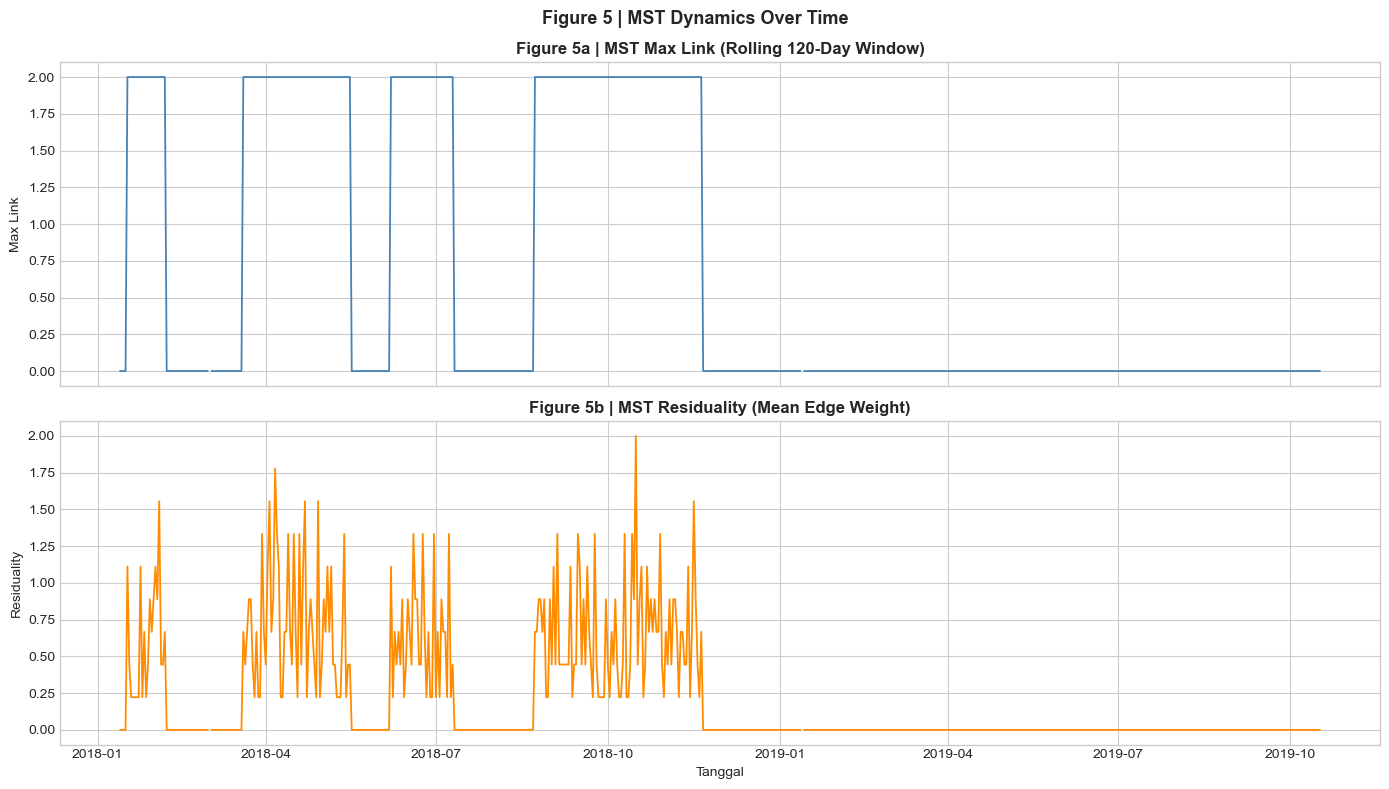

✅ MST Dynamics selesai.


In [6]:
def apply_rmt_filter_basic(corr_matrix, T, N):
    """Penyaringan noise sederhana via Marcenko-Pastur upper bound."""
    q      = T / N
    lambda_plus = (1 + 1 / np.sqrt(q)) ** 2   # batas atas eigenvalue noise

    vals, vecs = np.linalg.eigh(corr_matrix)
    # Pertahankan hanya eigenvalue > lambda_plus
    vals_filtered = np.where(vals > lambda_plus, vals, 0.0)
    C_filtered = vecs @ np.diag(vals_filtered) @ vecs.T

    # Normalisasi diagonal ke 1
    d = np.sqrt(np.diag(C_filtered))
    d[d == 0] = 1.0
    C_filtered = C_filtered / np.outer(d, d)
    return C_filtered


def calculate_rolling_mst_metrics(returns_df, window=120):
    """Menghitung Max Link dan Residuality dari MST secara rolling window."""
    max_links    = []
    resid_values = []
    dates        = []

    for i in range(window, len(returns_df)):
        window_data = returns_df.iloc[i - window:i]
        T, N        = window_data.shape

        corr          = window_data.corr().values
        corr_filtered = apply_rmt_filter_basic(corr, T, N)

        dist = np.sqrt(2 * (1 - np.clip(corr_filtered, -1, 1)))
        np.fill_diagonal(dist, 0)

        cols = window_data.columns.tolist()
        df_dist = pd.DataFrame(dist, index=cols, columns=cols)
        G   = nx.from_pandas_adjacency(df_dist)
        mst = nx.minimum_spanning_tree(G, weight='weight')

        edge_weights = [d['weight'] for _, _, d in mst.edges(data=True)]
        max_links.append(max(edge_weights) if edge_weights else np.nan)
        resid_values.append(np.mean(edge_weights) if edge_weights else np.nan)
        dates.append(returns_df.index[i])

    return pd.DataFrame({'Max Link': max_links, 'Residuality': resid_values}, index=dates)


print("⏳ Menghitung MST Dynamics (rolling window)... Harap tunggu.")
mst_metrics = calculate_rolling_mst_metrics(df_returns, window=WINDOW_SIZE)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(mst_metrics.index, mst_metrics['Max Link'], color='steelblue', linewidth=1.3)
axes[0].set_title('Figure 5a | MST Max Link (Rolling 120-Day Window)', fontweight='bold')
axes[0].set_ylabel('Max Link')

axes[1].plot(mst_metrics.index, mst_metrics['Residuality'], color='darkorange', linewidth=1.3)
axes[1].set_title('Figure 5b | MST Residuality (Mean Edge Weight)', fontweight='bold')
axes[1].set_ylabel('Residuality')
axes[1].set_xlabel('Tanggal')

plt.suptitle('Figure 5 | MST Dynamics Over Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ MST Dynamics selesai.")

---
## Sel 7 — Helper Functions: RMT Filter, Centrality, Rachev Ratio

In [7]:
# ── 7a. RMT Filter ────────────────────────────────────────────────────────────
def apply_rmt_filter(returns_data):
    """
    Filter noise matriks korelasi via Marcenko-Pastur upper bound.
    Eigenvalue di bawah lambda_plus (noise band) di-zeroed out.
    """
    T, N   = returns_data.shape
    corr   = returns_data.corr().values
    q      = T / N
    lambda_plus = (1 + 1 / np.sqrt(q)) ** 2

    vals, vecs   = np.linalg.eigh(corr)
    vals_filtered = np.where(vals > lambda_plus, vals, 0.0)
    C_filtered   = vecs @ np.diag(vals_filtered) @ vecs.T

    d = np.sqrt(np.diag(C_filtered))
    d[d == 0] = 1.0
    C_filtered = C_filtered / np.outer(d, d)
    np.fill_diagonal(C_filtered, 1.0)
    return C_filtered


# ── 7b. Eigenvector Centrality ────────────────────────────────────────────────
def compute_eigenvector_centrality(distance_matrix):
    """
    Mengukur kepentingan aset dalam jaringan berdasarkan
    eigenvector terbesar dari matriks adjacency (1/dist).
    """
    adj       = 1.0 / (np.array(distance_matrix) + 1e-8)
    _, vecs   = eigh(adj)
    pev       = np.abs(vecs[:, -1])   # principal eigenvector
    return pev / pev.sum()             # normalisasi ke sumbu 1


# ── 7c. Rachev Ratio ─────────────────────────────────────────────────────────
def calculate_rachev_ratio(returns, alpha=0.10):
    """
    Rachev Ratio = CVaR_upper / CVaR_lower pada level alpha.
    Mengukur asimetri tail-risk: imbal hasil ekor atas vs kerugian ekor bawah.
    """
    returns = np.array(returns)
    cutoff_lo = np.percentile(returns, alpha * 100)
    cutoff_hi = np.percentile(returns, (1 - alpha) * 100)

    cvar_lo = -returns[returns <= cutoff_lo].mean() if (returns <= cutoff_lo).any() else 1e-8
    cvar_hi =  returns[returns >= cutoff_hi].mean() if (returns >= cutoff_hi).any() else 0.0

    return cvar_hi / cvar_lo if cvar_lo > 0 else np.nan


# ── 7d. VaR & CVaR ───────────────────────────────────────────────────────────
def calculate_var_cvar(returns, confidence=0.95):
    """Menghitung Value at Risk dan Conditional VaR."""
    returns  = np.array(returns)
    var      = -np.percentile(returns, (1 - confidence) * 100)
    tail     = returns[returns <= -var]
    cvar     = -tail.mean() if len(tail) > 0 else var
    return var, cvar


# ── 7e. Sharpe Ratio ─────────────────────────────────────────────────────────
def calculate_sharpe(returns, rf_daily=0.0):
    """Annualized Sharpe Ratio."""
    excess = np.array(returns) - rf_daily
    if excess.std() == 0:
        return np.nan
    return (excess.mean() / excess.std()) * np.sqrt(252)


print("✅ Helper functions berhasil didefinisikan:")
print("   - apply_rmt_filter")
print("   - compute_eigenvector_centrality")
print("   - calculate_rachev_ratio")
print("   - calculate_var_cvar")
print("   - calculate_sharpe")

✅ Helper functions berhasil didefinisikan:
   - apply_rmt_filter
   - compute_eigenvector_centrality
   - calculate_rachev_ratio
   - calculate_var_cvar
   - calculate_sharpe


---
## Sel 8 — [INOVASI 1] Regime Detection via Gaussian HMM 2-State

⏳ Fitting Gaussian HMM 2-state...

✅ HMM selesai. Parameter terestimasi:
   State 0 (Bull) | Mean Vol = 0.024279 | Std = 0.005567
   State 1 (Bear) | Mean Vol = 0.061825 | Std = 0.028861
   Distribusi Regime: Bull=560 hari (75.4%), Bear=183 hari (24.6%)


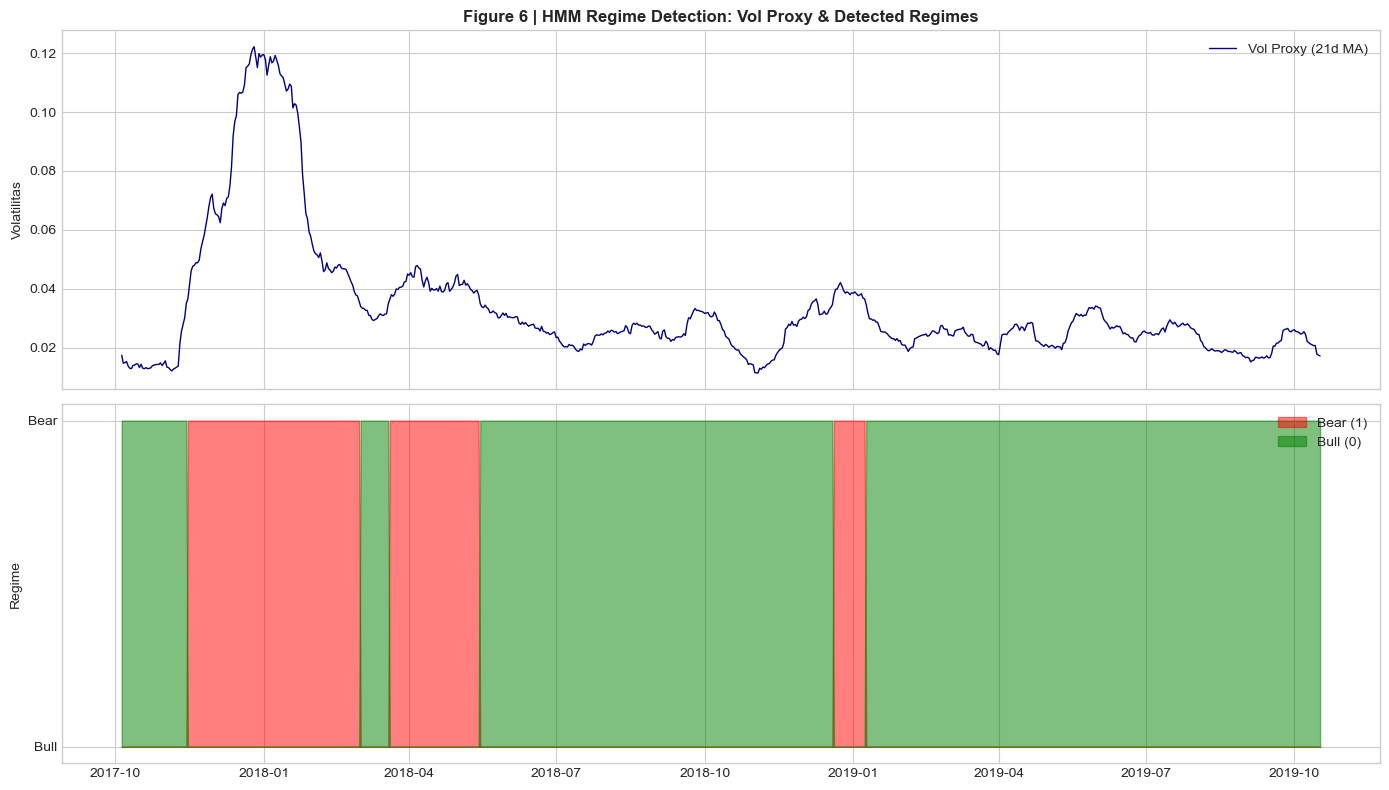

In [8]:
class GaussianHMM2State:
    """
    Hidden Markov Model dengan 2 state dan emisi Gaussian.
    - State 0 : Low Volatility  → Regime Bull
    - State 1 : High Volatility → Regime Bear

    Training menggunakan algoritma Baum-Welch (EM).
    Decoding menggunakan algoritma Viterbi.
    """

    def __init__(self, n_iter=200, tol=1e-4, random_state=42):
        self.n_iter       = n_iter
        self.tol          = tol
        self.random_state = random_state

    def _emission_prob(self, x, mu, sigma):
        """Probabilitas emisi Gaussian."""
        return stats_norm.pdf(x, loc=mu, scale=sigma + 1e-8)

    def _forward(self, X, A, pi, means, stds):
        T  = len(X)
        alpha = np.zeros((T, 2))
        alpha[0] = pi * self._emission_prob(X[0], means, stds)
        scale    = np.zeros(T)
        scale[0] = alpha[0].sum()
        alpha[0] /= scale[0] + 1e-300

        for t in range(1, T):
            alpha[t] = (alpha[t-1] @ A) * self._emission_prob(X[t], means, stds)
            scale[t]  = alpha[t].sum()
            alpha[t] /= scale[t] + 1e-300
        return alpha, scale

    def _backward(self, X, A, means, stds, scale):
        T    = len(X)
        beta = np.zeros((T, 2))
        beta[-1] = 1.0
        for t in range(T-2, -1, -1):
            beta[t]  = A @ (self._emission_prob(X[t+1], means, stds) * beta[t+1])
            beta[t] /= scale[t+1] + 1e-300
        return beta

    def fit(self, X):
        """Baum-Welch (EM) untuk mengestimasi parameter HMM."""
        np.random.seed(self.random_state)
        X = np.array(X, dtype=float)

        # Inisialisasi parameter
        self.means_ = np.array([X.mean() - X.std() * 0.5,
                                 X.mean() + X.std() * 0.5])
        self.stds_  = np.array([X.std(), X.std() * 1.5])
        self.transmat_ = np.array([[0.95, 0.05], [0.05, 0.95]])
        self.startprob_ = np.array([0.5, 0.5])

        prev_loglik = -np.inf
        for iteration in range(self.n_iter):
            # E-step
            alpha, scale = self._forward(X, self.transmat_, self.startprob_,
                                         self.means_, self.stds_)
            beta         = self._backward(X, self.transmat_, self.means_, self.stds_, scale)

            gamma = alpha * beta
            gamma /= gamma.sum(axis=1, keepdims=True) + 1e-300

            xi = np.zeros((len(X)-1, 2, 2))
            for t in range(len(X)-1):
                num = (alpha[t:t+1].T * self.transmat_
                       * self._emission_prob(X[t+1], self.means_, self.stds_)
                       * beta[t+1])
                xi[t] = num / (num.sum() + 1e-300)

            # M-step
            self.startprob_ = gamma[0] / gamma[0].sum()
            self.transmat_  = xi.sum(0) / xi.sum(0).sum(axis=1, keepdims=True)
            self.means_     = (gamma * X[:, None]).sum(0) / gamma.sum(0)
            self.stds_      = np.sqrt(
                (gamma * (X[:, None] - self.means_) ** 2).sum(0)
                / gamma.sum(0)
            )

            loglik = np.log(scale + 1e-300).sum()
            if abs(loglik - prev_loglik) < self.tol:
                break
            prev_loglik = loglik

        # Pastikan State 0 = Low Vol (Bull)
        if self.means_[0] > self.means_[1]:
            self.means_     = self.means_[::-1]
            self.stds_      = self.stds_[::-1]
            self.transmat_  = self.transmat_[::-1, ::-1]
            self.startprob_ = self.startprob_[::-1]
        return self

    def predict(self, X):
        """Prediksi state sequence menggunakan algoritma Viterbi."""
        X  = np.array(X, dtype=float)
        T  = len(X)
        V  = np.zeros((T, 2))
        ptr = np.zeros((T, 2), dtype=int)

        V[0] = np.log(self.startprob_ + 1e-300) + np.log(
            self._emission_prob(X[0], self.means_, self.stds_) + 1e-300
        )
        for t in range(1, T):
            for s in range(2):
                trans_prob = V[t-1] + np.log(self.transmat_[:, s] + 1e-300)
                ptr[t, s]  = np.argmax(trans_prob)
                V[t, s]    = trans_prob[ptr[t, s]] + np.log(
                    self._emission_prob(X[t], self.means_[s], self.stds_[s]) + 1e-300
                )

        states = np.zeros(T, dtype=int)
        states[-1] = np.argmax(V[-1])
        for t in range(T-2, -1, -1):
            states[t] = ptr[t+1, states[t+1]]
        return states


# ── Fitting HMM ──────────────────────────────────────────────────────────────
VOL_PROXY   = df_returns.std(axis=1).rolling(21).mean().dropna()

print("⏳ Fitting Gaussian HMM 2-state...")
hmm_model   = GaussianHMM2State(n_iter=200).fit(VOL_PROXY.values)
regime_pred = hmm_model.predict(VOL_PROXY.values)
regime_series = pd.Series(
    regime_pred, index=VOL_PROXY.index,
    name='Regime'   # 0=Bull, 1=Bear
)

n_bull = (regime_series == 0).sum()
n_bear = (regime_series == 1).sum()
print(f"\n✅ HMM selesai. Parameter terestimasi:")
print(f"   State 0 (Bull) | Mean Vol = {hmm_model.means_[0]:.6f} | Std = {hmm_model.stds_[0]:.6f}")
print(f"   State 1 (Bear) | Mean Vol = {hmm_model.means_[1]:.6f} | Std = {hmm_model.stds_[1]:.6f}")
print(f"   Distribusi Regime: Bull={n_bull} hari ({n_bull/len(regime_series)*100:.1f}%), "
      f"Bear={n_bear} hari ({n_bear/len(regime_series)*100:.1f}%)")

# ── Visualisasi Figure 6 ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel atas: Volatility proxy
axes[0].plot(VOL_PROXY.index, VOL_PROXY.values, color='navy', linewidth=1, label='Vol Proxy (21d MA)')
axes[0].set_ylabel('Volatilitas')
axes[0].set_title('Figure 6 | HMM Regime Detection: Vol Proxy & Detected Regimes', fontweight='bold')
axes[0].legend()

# Panel bawah: Regime
axes[1].fill_between(regime_series.index, regime_series.values,
                     color='red', alpha=0.5, label='Bear (1)')
axes[1].fill_between(regime_series.index, 1 - regime_series.values,
                     color='green', alpha=0.5, label='Bull (0)')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Bull', 'Bear'])
axes[1].set_ylabel('Regime')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

---
## Sel 9 — [INOVASI 2] Graph Gating dengan Optimasi θ Out-of-Sample

In [9]:
def get_mis_assets_rmt(returns_window, theta):
    """
    Maximum Independent Set (MIS) pada graf korelasi yang telah difilter RMT.
    Dua aset terhubung jika korelasi > theta (redundan, terlalu mirip).
    MIS memilih subset aset yang *tidak* terlalu berkorelasi satu sama lain.
    """
    corr_filtered = apply_rmt_filter(returns_window)
    N             = corr_filtered.shape[0]
    assets        = returns_window.columns.tolist()

    # Bangun graf: edge jika |corr| > theta
    G = nx.Graph()
    G.add_nodes_from(range(N))
    for i, j in combinations(range(N), 2):
        if abs(corr_filtered[i, j]) > theta:
            G.add_edge(i, j)

    # Greedy MIS: pilih node dengan degree terkecil terlebih dahulu
    remaining = set(G.nodes())
    selected  = []
    while remaining:
        # Pilih node dengan degree terkecil (paling independen)
        node = min(remaining, key=lambda n: G.degree(n))
        selected.append(node)
        # Hapus node dan tetangganya
        neighbors = set(G.neighbors(node))
        remaining -= {node} | neighbors

    return [assets[i] for i in selected]


def optimize_theta_oos(prior_returns, theta_grid=None):
    """
    Optimasi theta secara Out-of-Sample menggunakan expanding window
    untuk menghindari lookahead bias.

    Evaluasi: Sharpe Ratio rata-rata pada validation split.
    """
    if theta_grid is None:
        theta_grid = np.arange(0.2, 0.85, 0.1)

    if len(prior_returns) < 60:
        return 0.4   # default jika data terlalu sedikit

    split      = len(prior_returns) // 2
    train_ret  = prior_returns.iloc[:split]
    val_ret    = prior_returns.iloc[split:]

    if len(train_ret) < 30 or len(val_ret) < 10:
        return 0.4

    best_theta, best_sharpe = 0.4, -np.inf

    for theta in theta_grid:
        try:
            sel = get_mis_assets_rmt(train_ret, theta)
            if len(sel) < 2:
                continue
            # Portofolio equal-weight pada aset terpilih
            ew_ret = val_ret[sel].mean(axis=1)
            sr     = calculate_sharpe(ew_ret)
            if not np.isnan(sr) and sr > best_sharpe:
                best_sharpe = sr
                best_theta  = theta
        except Exception:
            continue

    return best_theta


def graph_gate(returns_window, theta):
    """Wrapper: Seleksi aset independen via MIS dari graf korelasi RMT."""
    sel = get_mis_assets_rmt(returns_window, theta)
    return sel if len(sel) >= 2 else returns_window.columns.tolist()


# ── Demo Graph Gate ───────────────────────────────────────────────────────────
demo_window = df_returns.iloc[-WINDOW_SIZE:]
demo_theta  = optimize_theta_oos(df_returns.iloc[-WINDOW_SIZE*2:-WINDOW_SIZE])
demo_sel    = graph_gate(demo_window, demo_theta)

print(f"✅ Graph Gate Demo (periode terakhir):")
print(f"   Optimal θ (OOS) = {demo_theta:.2f}")
print(f"   Aset terpilih MIS ({len(demo_sel)}/{N_ASSETS}): {demo_sel}")
print(f"   Aset dieliminasi : {[a for a in crypto_names if a not in demo_sel]}")

✅ Graph Gate Demo (periode terakhir):
   Optimal θ (OOS) = 0.40
   Aset terpilih MIS (10/10): ['BTC', 'ETH', 'XRP', 'USDT', 'BCH', 'LTC', 'BNB', 'EOS', 'XLM', 'TRX']
   Aset dieliminasi : []


---
## Sel 10 — [INOVASI 3] RS-AGGNM: Model Utama Tesis

In [10]:
class PortfolioStrategy:
    """Base class untuk semua strategi portofolio."""
    def get_weights(self, r, **kwargs):
        raise NotImplementedError


class RS_AGGNM(PortfolioStrategy):
    """
    Regime-Switching Adaptive Graph-Gated Network Markowitz.

    Langkah optimasi:
      1. Deteksi Regime via HMM  → gamma_t (agresif/defensif)
      2. Graph Gating via MIS    → subset aset S*
      3. Optimasi Network Markowitz pada subgraph S*:
         min  w^T Σ w + γ_t * (centrality_sub · w_sub).sum()
         s.t. Σ w = 1, w >= 0
              μ_w >= μ_max * 0.5   (Safety Constraint)
    """

    def __init__(self, gamma_bull=0.7, gamma_bear=0.05, hmm_model=None):
        self.gamma_bull = gamma_bull   # Agresif di Bull: bobot network tinggi
        self.gamma_bear = gamma_bear   # Defensif di Bear: minimasi varians
        self.hmm_model  = hmm_model

    def _detect_regime(self, vol_series):
        """Mengembalikan 0 (Bull) atau 1 (Bear) berdasarkan volatilitas terkini."""
        if self.hmm_model is None:
            return 0
        try:
            states = self.hmm_model.predict(vol_series.values)
            return int(states[-1])
        except Exception:
            return 0

    def get_weights(self, r, prior_returns=None, theta=0.4, **kwargs):
        """
        Parameters
        ----------
        r              : pd.DataFrame — return window saat ini
        prior_returns  : pd.DataFrame — data sebelum window (untuk OOS theta)
        theta          : float        — threshold korelasi graf (default fallback)
        """
        assets = r.columns.tolist()
        N      = len(assets)

        # ── Step 1: Deteksi Regime ────────────────────────────────────────────
        vol_proxy = r.std(axis=1).rolling(21, min_periods=5).mean().dropna()
        regime    = self._detect_regime(vol_proxy)
        gamma_t   = self.gamma_bull if regime == 0 else self.gamma_bear

        # ── Step 2: Graph Gating via MIS ─────────────────────────────────────
        if prior_returns is not None and len(prior_returns) >= 60:
            opt_theta = optimize_theta_oos(prior_returns)
        else:
            opt_theta = theta

        selected = graph_gate(r, opt_theta)
        r_sub    = r[selected]
        N_sub    = len(selected)

        # ── Step 3: Network Markowitz Optimization ────────────────────────────
        try:
            corr_filt = apply_rmt_filter(r_sub)
            std_sub   = r_sub.std().values
            Sigma_sub = corr_filt * np.outer(std_sub, std_sub)   # Cov matrix

            dist_sub  = np.sqrt(2 * (1 - np.clip(corr_filt, -1, 1)))
            cent_sub  = compute_eigenvector_centrality(dist_sub)

            mu_sub    = r_sub.mean().values
            mu_max    = mu_sub.max()

            # Objective: min w^T Σ w + γ (centrality · w)
            def objective(w):
                return float(w @ Sigma_sub @ w) + gamma_t * float((cent_sub * w).sum())

            constraints = [
                {'type': 'eq',   'fun': lambda w: w.sum() - 1},
                {'type': 'ineq', 'fun': lambda w: (mu_sub * w).sum() - mu_max * 0.5},
            ]
            bounds = [(0, 1)] * N_sub
            w0     = np.ones(N_sub) / N_sub

            result = minimize(
                objective, w0,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints,
                options={'maxiter': 500, 'ftol': 1e-9}
            )
            w_sub = result.x if result.success else w0

        except Exception:
            w_sub = np.ones(N_sub) / N_sub

        # Petakan bobot sub ke seluruh aset (aset tak terpilih → bobot 0)
        w_full = np.zeros(N)
        for idx, asset in enumerate(selected):
            w_full[assets.index(asset)] = w_sub[idx]

        # Normalisasi
        total = w_full.sum()
        if total > 0:
            w_full /= total

        return w_full


# ── Benchmark Strategies ─────────────────────────────────────────────────────
class EqualWeight(PortfolioStrategy):
    def get_weights(self, r, **kwargs):
        N = r.shape[1]
        return np.ones(N) / N


class MinVariance(PortfolioStrategy):
    def get_weights(self, r, **kwargs):
        N   = r.shape[1]
        Cov = r.cov().values
        constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
        bounds = [(0, 1)] * N
        w0     = np.ones(N) / N
        res    = minimize(lambda w: w @ Cov @ w, w0,
                          method='SLSQP', bounds=bounds, constraints=constraints)
        return res.x if res.success else w0


class MaxSharpe(PortfolioStrategy):
    def get_weights(self, r, **kwargs):
        N   = r.shape[1]
        mu  = r.mean().values
        Cov = r.cov().values
        def neg_sharpe(w):
            p_ret = mu @ w
            p_std = np.sqrt(w @ Cov @ w)
            return -p_ret / (p_std + 1e-8)
        constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
        bounds = [(0, 1)] * N
        w0     = np.ones(N) / N
        res    = minimize(neg_sharpe, w0,
                          method='SLSQP', bounds=bounds, constraints=constraints)
        return res.x if res.success else w0


# Inisialisasi model
model_rs_aggnm = RS_AGGNM(
    gamma_bull=0.7,
    gamma_bear=0.05,
    hmm_model=hmm_model
)

print("✅ RS-AGGNM dan benchmark strategies berhasil diinisialisasi:")
print("   - RS_AGGNM  (gamma_bull=0.7, gamma_bear=0.05)")
print("   - EqualWeight")
print("   - MinVariance")
print("   - MaxSharpe")

✅ RS-AGGNM dan benchmark strategies berhasil diinisialisasi:
   - RS_AGGNM  (gamma_bull=0.7, gamma_bear=0.05)
   - EqualWeight
   - MinVariance
   - MaxSharpe


---
## Sel 11 — Framework Backtesting dengan Turnover-Based Transaction Cost

In [11]:
def backtest_strategy(
    strategy,
    df_ret,
    window_size=120,
    rebalance_freq=7,
    tc=0.001,
    strategy_name='Strategy'
):
    """
    Backtesting rolling window dengan biaya transaksi berbasis turnover.

    TC = tc × Σ|w_new - w_old|  (proporsional terhadap perubahan bobot)

    Returns
    -------
    dict dengan kunci:
        'returns'  : pd.Series — return harian setelah TC
        'weights'  : pd.DataFrame — bobot aset per tanggal rebalancing
        'dates'    : list — tanggal rebalancing
    """
    n_days    = len(df_ret)
    N         = df_ret.shape[1]
    assets    = df_ret.columns.tolist()

    port_returns = []
    port_dates   = []
    weight_records = []
    weight_dates   = []

    w_prev = np.ones(N) / N   # Bobot awal equal-weight

    for start in range(window_size, n_days, rebalance_freq):
        end       = min(start + rebalance_freq, n_days)
        r_window  = df_ret.iloc[start - window_size:start]
        r_forward = df_ret.iloc[start:end]

        if len(r_window) < window_size // 2:
            continue

        # Khusus RS-AGGNM: kirim prior_returns untuk OOS theta
        try:
            if isinstance(strategy, RS_AGGNM):
                prior_start = max(0, start - window_size * 2)
                prior_end   = start - window_size
                prior_ret   = df_ret.iloc[prior_start:prior_end] if prior_end > prior_start else None
                w_new = strategy.get_weights(r_window, prior_returns=prior_ret)
            else:
                w_new = strategy.get_weights(r_window)
        except Exception as e:
            w_new = np.ones(N) / N

        # Turnover-based transaction cost
        turnover = np.abs(w_new - w_prev).sum()
        tc_cost  = tc * turnover

        # Return portofolio pada periode forward
        for date in r_forward.index:
            daily_ret = (r_forward.loc[date].values * w_new).sum() - tc_cost / rebalance_freq
            port_returns.append(daily_ret)
            port_dates.append(date)

        weight_records.append(w_new)
        weight_dates.append(df_ret.index[start])
        w_prev = w_new.copy()

    returns_series = pd.Series(port_returns, index=port_dates, name=strategy_name)
    weights_df     = pd.DataFrame(weight_records, index=weight_dates, columns=assets)

    return {
        'returns' : returns_series,
        'weights' : weights_df,
        'dates'   : weight_dates
    }


# ── Jalankan Backtesting untuk Semua Strategi ─────────────────────────────────
strategies = {
    'RS-AGGNM'   : model_rs_aggnm,
    'EqualWeight': EqualWeight(),
    'MinVariance': MinVariance(),
    'MaxSharpe'  : MaxSharpe(),
}

results = {}
for name, strat in strategies.items():
    print(f"⏳ Backtesting: {name}...")
    results[name] = backtest_strategy(
        strat, df_returns,
        window_size=WINDOW_SIZE,
        rebalance_freq=REBALANCE_FREQ,
        tc=TRANS_COST,
        strategy_name=name
    )
    print(f"   ✅ Selesai. Observasi: {len(results[name]['returns'])}")

print("\n✅ Semua backtesting selesai.")

⏳ Backtesting: RS-AGGNM...
   ✅ Selesai. Observasi: 643
⏳ Backtesting: EqualWeight...
   ✅ Selesai. Observasi: 643
⏳ Backtesting: MinVariance...
   ✅ Selesai. Observasi: 643
⏳ Backtesting: MaxSharpe...
   ✅ Selesai. Observasi: 643

✅ Semua backtesting selesai.


---
## Sel 12 — Cumulative P&L (Table 2) & Equity Curve (Figure 7)

TABLE 2 | Cumulative P&L (Sampled: Jan, May, Sep each year)
            RS-AGGNM  EqualWeight  MinVariance  MaxSharpe
2018-05-01    0.5502       0.5481       0.9794     0.5068
2018-05-02    0.5523       0.5565       0.9747     0.5084
2018-05-03    0.5302       0.5675       0.9787     0.4942
2018-05-04    0.5207       0.5667       0.9789     0.4845
2018-05-05    0.5208       0.5838       0.9780     0.4916
2018-05-06    0.5130       0.5702       0.9774     0.4811
2018-05-07    0.5085       0.5541       0.9753     0.4822
2018-09-01    0.2616       0.2541       0.9654     0.1920
2018-09-02    0.2619       0.2532       0.9681     0.1909
2018-09-03    0.2621       0.2502       0.9683     0.1904
2018-09-04    0.2623       0.2519       0.9719     0.1918
2018-09-05    0.2645       0.2183       0.9585     0.1739
2018-09-06    0.2627       0.2180       0.9462     0.1764
2018-09-07    0.2641       0.2123       0.9475     0.1732
2019-01-01    0.1138       0.1242       0.7779     0.1115
2019-01-02  

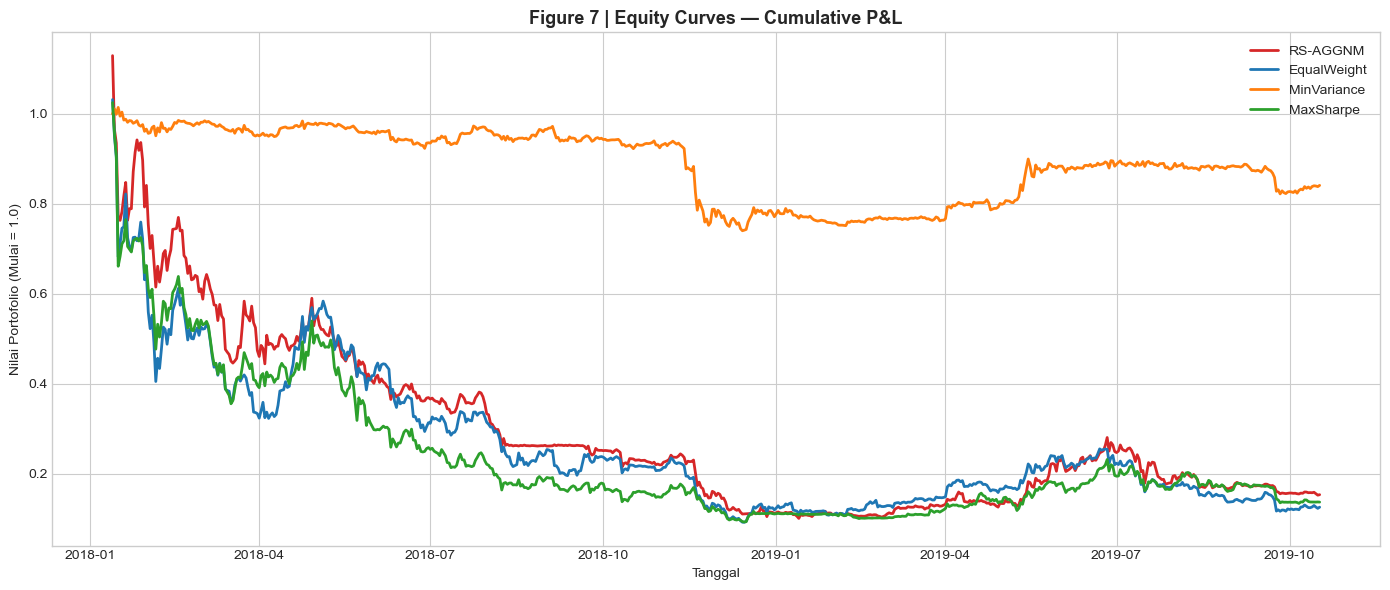

In [12]:
# ── Kumpulkan return series ───────────────────────────────────────────────────
all_returns = pd.DataFrame({
    name: res['returns'] for name, res in results.items()
}).dropna()

# Cumulative P&L
cum_pnl = (1 + all_returns).cumprod()

# Sample pada Januari, Mei, September setiap tahun
sample_months = [1, 5, 9]
sampled_idx   = cum_pnl[
    cum_pnl.index.month.isin(sample_months) &
    (cum_pnl.index.day <= 7)
].drop_duplicates()

print("TABLE 2 | Cumulative P&L (Sampled: Jan, May, Sep each year)")
print("=" * 75)
print(sampled_idx.round(4).to_string())

# Figure 7: Equity Curve
fig, ax = plt.subplots(figsize=(14, 6))
colors  = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c']
for (name, col) in zip(cum_pnl.columns, colors):
    ax.plot(cum_pnl.index, cum_pnl[name], label=name, linewidth=2, color=col)

ax.set_title('Figure 7 | Equity Curves — Cumulative P&L', fontsize=13, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Nilai Portofolio (Mulai = 1.0)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Sel 13 — VaR 95% (Table 3)

In [13]:
def rolling_var_table(returns_df, window=120, confidence=0.95, sample_months=(1,5,9)):
    """Menghitung rolling VaR 95% dan sampling pada bulan-bulan tertentu."""
    var_records = {}
    for col in returns_df.columns:
        rolling_var = []
        for i in range(window, len(returns_df)):
            r_win = returns_df[col].iloc[i - window:i]
            var, _ = calculate_var_cvar(r_win, confidence)
            rolling_var.append(var)
        var_records[col] = pd.Series(
            rolling_var, index=returns_df.index[window:]
        )
    var_df = pd.DataFrame(var_records)
    sampled = var_df[
        var_df.index.month.isin(sample_months) &
        (var_df.index.day <= 7)
    ].drop_duplicates()
    return sampled


table3 = rolling_var_table(all_returns)
print("TABLE 3 | Rolling VaR 95% (Sampled: Jan, May, Sep each year)")
print("=" * 65)
print(table3.round(4).to_string())

TABLE 3 | Rolling VaR 95% (Sampled: Jan, May, Sep each year)
            RS-AGGNM  EqualWeight  MinVariance  MaxSharpe
2018-09-01    0.0545       0.0693       0.0075     0.0817
2018-09-06    0.0545       0.0765       0.0077     0.0903
2018-09-07    0.0545       0.0765       0.0080     0.0903
2019-01-01    0.0674       0.0949       0.0173     0.0821
2019-01-04    0.0674       0.0908       0.0173     0.0786
2019-05-01    0.0323       0.0388       0.0072     0.0262
2019-05-04    0.0323       0.0368       0.0064     0.0262
2019-05-05    0.0323       0.0368       0.0064     0.0332
2019-05-07    0.0323       0.0368       0.0064     0.0340
2019-09-01    0.0681       0.0696       0.0118     0.0664
2019-09-07    0.0681       0.0696       0.0118     0.0647


---
## Sel 14 — Sharpe Ratio (Table 4) & Rachev Ratio (Table 5)

In [14]:
def rolling_ratio_table(returns_df, ratio_func, window=120, sample_months=(1,5,9)):
    """Reusable: hitung rolling ratio dan sample."""
    records = {}
    for col in returns_df.columns:
        vals = []
        for i in range(window, len(returns_df)):
            r_win = returns_df[col].iloc[i - window:i]
            vals.append(ratio_func(r_win))
        records[col] = pd.Series(vals, index=returns_df.index[window:])
    df = pd.DataFrame(records)
    return df[
        df.index.month.isin(sample_months) & (df.index.day <= 7)
    ].drop_duplicates()


table4 = rolling_ratio_table(all_returns, calculate_sharpe)
print("TABLE 4 | Rolling Sharpe Ratio (Annualized, Sampled: Jan, May, Sep)")
print("=" * 65)
print(table4.round(4).to_string())

print()

table5 = rolling_ratio_table(all_returns, calculate_rachev_ratio)
print("TABLE 5 | Rolling Rachev Ratio (α=10%, Sampled: Jan, May, Sep)")
print("=" * 65)
print(table5.round(4).to_string())

TABLE 4 | Rolling Sharpe Ratio (Annualized, Sampled: Jan, May, Sep)
            RS-AGGNM  EqualWeight  MinVariance  MaxSharpe
2018-09-01   -3.3047      -2.5485      -0.3334    -2.5066
2018-09-02   -3.2510      -2.3823      -0.3295    -2.3710
2018-09-03   -3.2461      -2.5052      -0.2281    -2.4327
2018-09-04   -3.1681      -2.4674      -0.2077    -2.3783
2018-09-05   -3.1184      -2.3510      -0.0524    -2.3634
2018-09-06   -3.0517      -2.6484      -0.4956    -2.5925
2018-09-07   -3.3269      -2.6577      -0.7869    -2.6575
2019-01-01   -2.7272      -1.8006      -2.3024    -1.5560
2019-01-02   -2.6717      -1.6621      -2.2046    -1.5272
2019-01-03   -2.6219      -1.5586      -2.1398    -1.5293
2019-01-04   -2.7182      -1.3260      -2.0932    -1.2582
2019-01-05   -2.7118      -1.2733      -1.9717    -1.3177
2019-01-06   -2.7363      -1.1711      -1.9824    -1.2513
2019-01-07   -2.6564      -0.8706      -1.7218    -1.0720
2019-05-01    1.1420       1.5888       0.9326     1.4744
2019

---
## Sel 15 — Phase Analysis (Table 6)

In [15]:
# Definisikan fase pasar (sesuaikan dengan data aktual)
phases = {
    'Bearish'  : ('2018-01-01', '2018-12-31'),
    'Recovery' : ('2019-01-01', '2020-02-29'),
    'Bull 2021': ('2020-10-01', '2021-11-30'),
    'Crypto Winter': ('2022-01-01', '2022-12-31'),
    'Stable'   : ('2023-01-01', '2023-12-31'),
}

phase_results = []
for phase_name, (start, end) in phases.items():
    phase_ret = all_returns.loc[start:end]
    if len(phase_ret) < 10:
        continue
    row = {'Phase': phase_name, 'N_Days': len(phase_ret)}
    for col in all_returns.columns:
        r = phase_ret[col]
        row[f'{col}_CumRet'] = (1 + r).prod() - 1
        row[f'{col}_Sharpe']  = calculate_sharpe(r)
    phase_results.append(row)

table6 = pd.DataFrame(phase_results).set_index('Phase')
print("TABLE 6 | Phase Analysis — Performa per Fase Pasar")
print("=" * 80)
print(table6.round(4).to_string())

TABLE 6 | Phase Analysis — Performa per Fase Pasar
          N_Days  RS-AGGNM_CumRet  RS-AGGNM_Sharpe  EqualWeight_CumRet  EqualWeight_Sharpe  MinVariance_CumRet  MinVariance_Sharpe  MaxSharpe_CumRet  MaxSharpe_Sharpe
Phase                                                                                                                                                                 
Bearish      353          -0.8879          -2.0686             -0.8800             -1.5306             -0.2288             -1.2490           -0.8891           -1.7320
Recovery     290           0.3721           0.7598              0.0502              0.3624              0.0903              0.7124            0.2381            0.6188


---
## Sel 16 — Regime-Conditional Analysis (Table 7)

In [16]:
# Align regime series dengan return series
regime_aligned = regime_series.reindex(all_returns.index, method='ffill')

regime_rows = []
for regime_label, regime_val in [('Bull (State=0)', 0), ('Bear (State=1)', 1)]:
    mask     = (regime_aligned == regime_val)
    cond_ret = all_returns[mask]
    if len(cond_ret) < 5:
        continue
    row = {'Regime': regime_label, 'N_Days': int(mask.sum())}
    for col in all_returns.columns:
        r = cond_ret[col]
        row[f'{col}_MeanRet'] = r.mean() * 252     # annualized
        row[f'{col}_Std']     = r.std() * np.sqrt(252)
        row[f'{col}_Sharpe']  = calculate_sharpe(r)
    regime_rows.append(row)

table7 = pd.DataFrame(regime_rows).set_index('Regime')
print("TABLE 7 | Regime-Conditional Performance (HMM Bull vs Bear)")
print("=" * 80)
print(table7.round(4).to_string())
print("\n⭐ Kontribusi khusus tesis: Tabel ini menunjukkan keunggulan RS-AGGNM")
print("   dalam adaptasi gamma (agresif/defensif) berdasarkan deteksi regime.")

TABLE 7 | Regime-Conditional Performance (HMM Bull vs Bear)
                N_Days  RS-AGGNM_MeanRet  RS-AGGNM_Std  RS-AGGNM_Sharpe  EqualWeight_MeanRet  EqualWeight_Std  EqualWeight_Sharpe  MinVariance_MeanRet  MinVariance_Std  MinVariance_Sharpe  MaxSharpe_MeanRet  MaxSharpe_Std  MaxSharpe_Sharpe
Regime                                                                                                                                                                                                                                         
Bull (State=0)     519           -0.5466        0.5590          -0.9787              -0.6919           0.6160             -1.1244              -0.0811           0.1316             -0.6169            -0.5201         0.6040           -0.8619
Bear (State=1)     124           -0.4949        0.8464          -0.5871              -0.0266           0.9564             -0.0279               0.0312           0.1224              0.2559            -0.7228         0.825

---
## Sel 17 — Summary Performance Table (Figure 8)

TABLE | Overall Performance Summary
             Cum Return  Ann Return  Ann Vol  Sharpe  Rachev  VaR 95%  CVaR 95%  Max Drawdown
Strategy                                                                                     
RS-AGGNM        -0.8462     -0.5199   0.6240 -0.8606  0.9262   0.0648    0.0986       -0.9105
EqualWeight     -0.8739     -0.5559   0.6940 -0.8127  0.8028   0.0775    0.1160       -0.9103
MinVariance     -0.1592     -0.0657   0.1299 -0.4583  0.9091   0.0115    0.0207       -0.2701
MaxSharpe       -0.8627     -0.5407   0.6518 -0.8586  0.8329   0.0750    0.1068       -0.9090


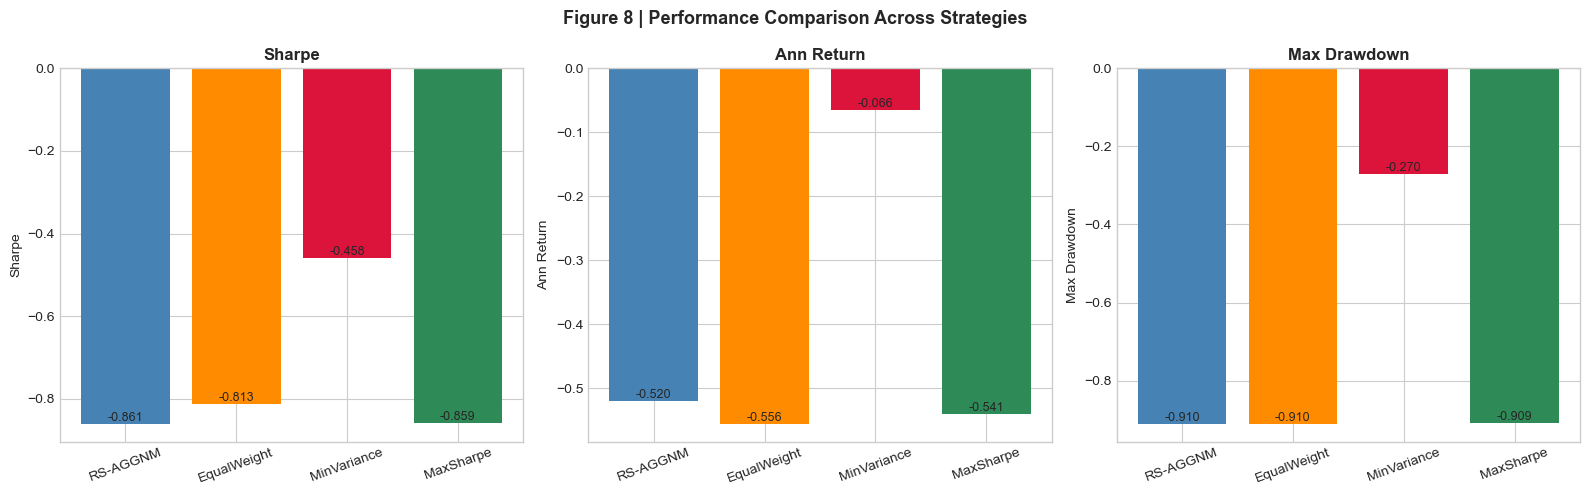

In [17]:
summary_perf = []
for col in all_returns.columns:
    r        = all_returns[col]
    cum_ret  = (1 + r).prod() - 1
    ann_ret  = (1 + r).prod() ** (252 / len(r)) - 1
    ann_vol  = r.std() * np.sqrt(252)
    sharpe   = calculate_sharpe(r)
    rachev   = calculate_rachev_ratio(r)
    var95, cvar95 = calculate_var_cvar(r, 0.95)

    # Max Drawdown
    cum_curve = (1 + r).cumprod()
    rolling_max = cum_curve.cummax()
    drawdown    = (cum_curve - rolling_max) / rolling_max
    max_dd      = drawdown.min()

    summary_perf.append({
        'Strategy'    : col,
        'Cum Return'  : round(cum_ret, 4),
        'Ann Return'  : round(ann_ret, 4),
        'Ann Vol'     : round(ann_vol, 4),
        'Sharpe'      : round(sharpe, 4),
        'Rachev'      : round(rachev, 4),
        'VaR 95%'     : round(var95, 4),
        'CVaR 95%'    : round(cvar95, 4),
        'Max Drawdown': round(max_dd, 4),
    })

summary_df = pd.DataFrame(summary_perf).set_index('Strategy')
print("TABLE | Overall Performance Summary")
print("=" * 70)
print(summary_df.to_string())

# Figure 8: Bar chart Sharpe vs Strategy
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ['Sharpe', 'Ann Return', 'Max Drawdown']
colors = ['steelblue', 'darkorange', 'crimson', 'seagreen']

for ax, metric in zip(axes, metrics_to_plot):
    vals  = summary_df[metric]
    bars  = ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(f'{metric}', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Figure 8 | Performance Comparison Across Strategies',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Sel 18 — Visualisasi Evolusi Bobot RS-AGGNM (Figure 9)

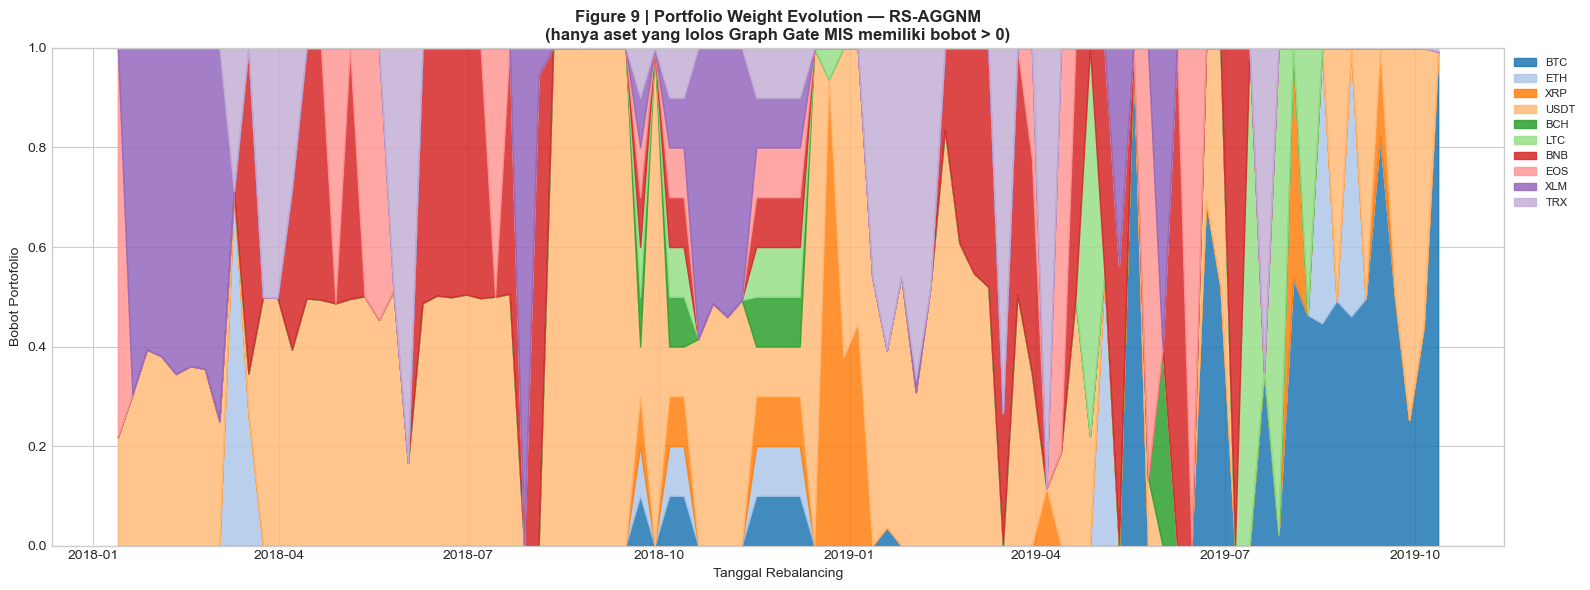


Rata-rata Alokasi per Aset (RS-AGGNM):
USDT    0.3606
BNB     0.1451
XLM     0.1041
BTC     0.1003
TRX     0.0929
EOS     0.0700
LTC     0.0441
ETH     0.0361
XRP     0.0350
BCH     0.0119


In [18]:
W_df    = results['RS-AGGNM']['weights']
w_dates = W_df.index
W_mat   = W_df.values

fig, ax = plt.subplots(figsize=(16, 6))
bottom  = np.zeros(len(w_dates))

colors_asset = plt.cm.tab20.colors
for i, asset in enumerate(W_df.columns):
    col = colors_asset[i % len(colors_asset)]
    ax.fill_between(w_dates, bottom, bottom + W_mat[:, i],
                    label=asset, color=col, alpha=0.85)
    bottom += W_mat[:, i]

ax.set_ylim(0, 1)
ax.set_xlabel('Tanggal Rebalancing')
ax.set_ylabel('Bobot Portofolio')
ax.set_title(
    'Figure 9 | Portfolio Weight Evolution — RS-AGGNM\n'
    '(hanya aset yang lolos Graph Gate MIS memiliki bobot > 0)',
    fontsize=12, fontweight='bold'
)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout()
plt.show()

# Hitung rata-rata alokasi per aset
avg_alloc = W_df.mean().sort_values(ascending=False)
print("\nRata-rata Alokasi per Aset (RS-AGGNM):")
print(avg_alloc.round(4).to_string())

---
## Sel 19 — Ekspor Hasil ke Excel

In [19]:
OUTPUT_FILE = 'RS_AGGNM_Results.xlsx'

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    # Metadata
    pd.DataFrame({
        'Parameter': ['WINDOW_SIZE', 'REBALANCE_FREQ', 'TRANS_COST', 'gamma_bull', 'gamma_bear'],
        'Value'    : [WINDOW_SIZE, REBALANCE_FREQ, TRANS_COST, 0.7, 0.05]
    }).to_excel(writer, sheet_name='Config', index=False)

    # Table 1: Summary Statistics
    summary.to_excel(writer, sheet_name='Table1_SummaryStats')

    # Table 2: Cumulative P&L
    sampled_idx.to_excel(writer, sheet_name='Table2_CumPnL')

    # Table 3: VaR
    table3.to_excel(writer, sheet_name='Table3_VaR95')

    # Table 4: Sharpe
    table4.to_excel(writer, sheet_name='Table4_Sharpe')

    # Table 5: Rachev
    table5.to_excel(writer, sheet_name='Table5_Rachev')

    # Table 6: Phase Analysis
    table6.to_excel(writer, sheet_name='Table6_PhaseAnalysis')

    # Table 7: Regime-Conditional
    table7.to_excel(writer, sheet_name='Table7_RegimeConditional')

    # Summary Performance
    summary_df.to_excel(writer, sheet_name='Summary_Performance')

    # Raw Returns
    all_returns.to_excel(writer, sheet_name='Raw_Returns')

    # Weights RS-AGGNM
    W_df.to_excel(writer, sheet_name='Weights_RS-AGGNM')

    # Regime Series
    regime_series.to_frame('Regime').to_excel(writer, sheet_name='HMM_Regimes')

print(f"✅ Hasil diekspor ke: {OUTPUT_FILE}")
print("   Sheet yang tersedia:")
print("   Config | Table1-7 | Summary_Performance | Raw_Returns | Weights_RS-AGGNM | HMM_Regimes")

✅ Hasil diekspor ke: RS_AGGNM_Results.xlsx
   Sheet yang tersedia:
   Config | Table1-7 | Summary_Performance | Raw_Returns | Weights_RS-AGGNM | HMM_Regimes


---
## Kesimpulan

Notebook ini mengimplementasikan kerangka kerja **RS-AGGNM** secara penuh:

| Inovasi | Komponen | Fungsi Kunci |
|---------|----------|--------------|
| Inovasi 1 | Gaussian HMM 2-state | `GaussianHMM2State.fit()`, `.predict()` |
| Inovasi 2 | Graph Gating MIS + OOS θ | `get_mis_assets_rmt()`, `optimize_theta_oos()` |
| Inovasi 3 | RS-AGGNM Framework | `RS_AGGNM.get_weights()` |

**Referensi:** Giudici et al. (2020), _Network-adjusted Markowitz portfolios_.